# IE7615 Generative Project — Milestone #1
## Image Captioning with CLIP Encoder + GPT-2 Decoder

**Course:** IE7615 Neural Networks/Deep Learning SEC 02, Spring 2026  
**Group 8:** Quoc Hung Le, Khoa Tran, Hassan Alfareed  
**Milestone:** #1 — Data Pipeline & Environment Setup  

---

### Objective

Build a reproducible data pipeline that:
1. Downloads and preprocesses a curated subset of Flickr30k (3,000 image-caption pairs)
2. Extracts visual embeddings using OpenAI CLIP (ViT-B/32)
3. Tokenizes captions using GPT-2 tokenizer
4. Validates the pipeline with 5 sample image-caption test runs

### Architecture Preview

```
Image -> CLIP ViT-B/32 -> 512-d embedding -> [ProjectionHead (M2)] -> GPT-2 prefix
                                                                        |
Caption tokens <- GPT-2 Decoder <- prefix-conditioned generation
```

---
## 0. Reproducibility & Configuration

In [3]:
import os
import sys
import random
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch

PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__")) + "/../"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


@dataclass
class Config:
    """Central configuration for the pipeline."""

    project_root: str = PROJECT_ROOT
    data_raw_dir: str = ""
    data_processed_dir: str = ""
    embeddings_dir: str = ""
    outputs_dir: str = ""

    dataset_name: str = "flickr30k"
    hf_dataset_id: str = "nlphuji/flickr30k"
    hf_dataset_revision: str = "refs/convert/parquet"
    subset_size: int = 3000
    val_ratio: float = 0.1
    test_ratio: float = 0.1
    min_caption_length: int = 8
    max_caption_length: int = 60

    clip_model_name: str = "openai/clip-vit-base-patch32"
    clip_embedding_dim: int = 512

    gpt2_model_name: str = "gpt2"
    gpt2_embedding_dim: int = 768
    max_token_length: int = 50

    seed: int = 42
    device: str = ""

    def __post_init__(self):
        self.data_raw_dir = os.path.join(self.project_root, "data", "raw")
        self.data_processed_dir = os.path.join(self.project_root, "data", "processed")
        self.embeddings_dir = os.path.join(self.project_root, "data", "embeddings")
        self.outputs_dir = os.path.join(self.project_root, "outputs")

        if not self.device:
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                self.device = "mps"
            elif torch.cuda.is_available():
                self.device = "cuda"
            else:
                self.device = "cpu"


cfg = Config()


def set_seed(seed: int) -> None:
    """Set random seed across all frameworks for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(cfg.seed)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("milestone1")

logger.info(f"Device: {cfg.device}")
logger.info(f"PyTorch: {torch.__version__}")
logger.info(f"Project root: {cfg.project_root}")

2026-02-27 18:13:53 [INFO] Device: mps
2026-02-27 18:13:53 [INFO] PyTorch: 2.10.0
2026-02-27 18:13:53 [INFO] Project root: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../


---
## 1. Environment Verification

In [4]:
import transformers
import datasets as hf_datasets
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt

env_info = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "transformers": transformers.__version__,
    "datasets": hf_datasets.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "device": cfg.device,
    "mps_available": str(hasattr(torch.backends, "mps") and torch.backends.mps.is_available()),
    "mps_built": str(hasattr(torch.backends, "mps") and torch.backends.mps.is_built()),
}

for pkg, ver in env_info.items():
    print(f"{pkg:20s}: {ver}")

python              : 3.13.7
pytorch             : 2.10.0
transformers        : 5.2.0
datasets            : 4.6.0
numpy               : 2.4.2
matplotlib          : 3.10.8
device              : mps
mps_available       : True
mps_built           : True


---
## 2. Directory Setup

In [5]:
dirs_to_create = [
    cfg.data_raw_dir,
    cfg.data_processed_dir,
    cfg.embeddings_dir,
    os.path.join(cfg.outputs_dir, "logs"),
    os.path.join(cfg.outputs_dir, "figures"),
    os.path.join(cfg.outputs_dir, "samples"),
    os.path.join(cfg.outputs_dir, "checkpoints"),
]

for d in dirs_to_create:
    Path(d).mkdir(parents=True, exist_ok=True)

logger.info("All directories ready.")

2026-02-27 18:13:55 [INFO] All directories ready.


---
## 3. Dataset Loading — Flickr30k

**Dataset choice justification:**  
Flickr30k provides 31,783 images with 5 human-annotated captions each. It is a standard benchmark alongside COCO Captions for image captioning research. Key advantages: (1) same multi-reference structure as COCO for robust metric computation in M3, (2) straightforward download via HuggingFace without separate API registration, (3) diverse everyday scenes covering people, animals, objects, and activities.

We subsample 3,000 images to keep compute reasonable on Apple Silicon while maintaining sufficient diversity for meaningful training.

In [6]:
from datasets import load_dataset

# nlphuji/flickr30k has a legacy flickr30k.py that datasets>=4.0 rejects.
# Loading from the auto-converted parquet branch bypasses it entirely.
logger.info(f"Loading {cfg.hf_dataset_id} (revision={cfg.hf_dataset_revision})...")
raw_dataset = load_dataset(
    cfg.hf_dataset_id,
    split="test",
    revision=cfg.hf_dataset_revision,
)

logger.info(f"Total samples loaded: {len(raw_dataset)}")
print(f"Dataset features: {raw_dataset.features}")
print(f"Sample keys: {list(raw_dataset[0].keys())}")


2026-02-27 18:13:55 [INFO] Loading nlphuji/flickr30k (revision=refs/convert/parquet)...


2026-02-27 18:13:55 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/refs%2Fconvert%2Fparquet/README.md "HTTP/1.1 404 Not Found"
2026-02-27 18:13:55 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/nlphuji/flickr30k/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 200 OK"
2026-02-27 18:13:55 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/flickr30k.py "HTTP/1.1 404 Not Found"
2026-02-27 18:13:55 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/nlphuji/flickr30k/nlphuji/flickr30k.py "HTTP/1.1 404 Not Found"
2026-02-27 18:13:55 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/README.md "HTTP/1.1 404 Not Found"
2026-02-27 18:13:55 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/nlphuji/flickr30k/revision/cd91f9a00273ce2e1584511cba8c10b917c48

Dataset features: {'image': Image(mode=None, decode=True), 'caption': List(Value('string')), 'sentids': List(Value('string')), 'split': Value('string'), 'img_id': Value('string'), 'filename': Value('string')}
Sample keys: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename']


---
## 4. Data Preprocessing

Steps:
1. Flatten multi-caption entries (one image may have 5 captions)
2. Select one caption per image randomly (keep all 5 in `captions_all` for M3 metrics)
3. Filter captions by word count
4. Basic text normalization (lowercase, collapse whitespace, strip non-alphanumeric)
5. Subsample to `subset_size` unique images
6. Train / validation / test split (80/10/10)

In [7]:
import re
import unicodedata


def normalize_caption(text: str) -> str:
    """Apply basic text normalization to a caption string."""
    text = unicodedata.normalize("NFKD", text)
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s.,!?\'\-]", "", text)
    return text


def flatten_and_clean(
    dataset, subset_size: int, min_len: int, max_len: int
) -> List[Dict]:
    """Flatten multi-caption dataset and apply filtering.

    Returns a list of dicts with keys: image, caption, captions_all, image_id.
    Each image gets one randomly selected caption to avoid data leakage
    across splits. All reference captions are preserved for metric computation.
    """
    image_caption_map = {}

    for idx, sample in enumerate(dataset):
        image = sample["image"]
        captions = sample.get("caption", [])
        if isinstance(captions, str):
            captions = [captions]

        cleaned = []
        for cap in captions:
            c = normalize_caption(cap)
            word_count = len(c.split())
            if min_len <= word_count <= max_len:
                cleaned.append(c)

        if not cleaned:
            continue

        image_caption_map[idx] = {
            "image": image,
            "captions_all": cleaned,
            "caption": random.choice(cleaned),
            "image_id": idx,
        }

        if len(image_caption_map) >= subset_size:
            break

    records = list(image_caption_map.values())
    logger.info(f"Cleaned dataset: {len(records)} unique images")
    return records


cleaned_data = flatten_and_clean(
    raw_dataset,
    subset_size=cfg.subset_size,
    min_len=cfg.min_caption_length,
    max_len=cfg.max_caption_length,
)

print(f"Total image-caption pairs: {len(cleaned_data)}")
print(f"Sample caption: '{cleaned_data[0]['caption']}'")
print(f"Reference captions for sample 0: {cleaned_data[0]['captions_all'][:3]}")

2026-02-27 18:14:04 [INFO] Cleaned dataset: 3000 unique images


Total image-caption pairs: 3000
Sample caption: 'two young guys with shaggy hair look at their hands while hanging out in the yard.'
Reference captions for sample 0: ['two young guys with shaggy hair look at their hands while hanging out in the yard.', 'two young, white males are outside near many bushes.', 'two men in green shirts are standing in a yard.']


In [8]:
def split_dataset(
    data: List[Dict], val_ratio: float, test_ratio: float, seed: int
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """Split data into train/val/test by shuffled indices."""
    n = len(data)
    indices = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(indices)

    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)

    test_idx = indices[:n_test]
    val_idx = indices[n_test : n_test + n_val]
    train_idx = indices[n_test + n_val :]

    return (
        [data[i] for i in train_idx],
        [data[i] for i in val_idx],
        [data[i] for i in test_idx],
    )


train_data, val_data, test_data = split_dataset(
    cleaned_data, cfg.val_ratio, cfg.test_ratio, cfg.seed
)

logger.info(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

2026-02-27 18:14:04 [INFO] Train: 2400 | Val: 300 | Test: 300


### 4.1 Caption Length Distribution

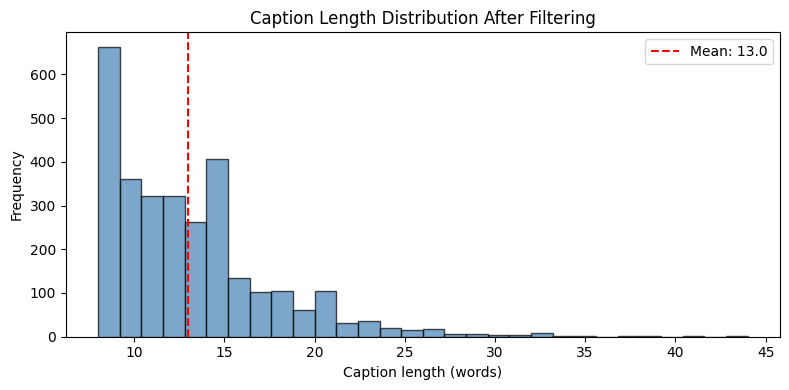

Mean: 13.0 | Std: 4.4
Min: 8 | Max: 44


In [9]:
caption_lengths = [len(d["caption"].split()) for d in cleaned_data]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(caption_lengths, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.set_xlabel("Caption length (words)")
ax.set_ylabel("Frequency")
ax.set_title("Caption Length Distribution After Filtering")
ax.axvline(
    np.mean(caption_lengths), color="red", linestyle="--",
    label=f"Mean: {np.mean(caption_lengths):.1f}",
)
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.outputs_dir, "figures", "caption_length_dist.png"), dpi=150
)
plt.show()

print(f"Mean: {np.mean(caption_lengths):.1f} | Std: {np.std(caption_lengths):.1f}")
print(f"Min: {min(caption_lengths)} | Max: {max(caption_lengths)}")

---
## 5. CLIP Image Encoder — Embedding Pipeline

We use `openai/clip-vit-base-patch32` to extract 512-dimensional image embeddings.  
The encoder is frozen throughout the entire project (no gradient updates).  

**MPS note:** CLIP inference runs well on Apple Silicon MPS backend. Batch size 64 fits comfortably in 16GB unified memory.

In [10]:
from transformers import CLIPModel, CLIPProcessor


class CLIPImageEncoder:
    """Wrapper around CLIP ViT-B/32 for image embedding extraction."""

    def __init__(self, model_name: str, device: str):
        self.device = device
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name)

        # Move to device after loading to avoid MPS issues with direct load
        self.model = self.model.to(device)
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        total_params = sum(p.numel() for p in self.model.parameters())
        logger.info(f"CLIP loaded: {model_name} on {device} ({total_params:,} params)")

    @torch.no_grad()
    def encode_image(self, image: Image.Image) -> torch.Tensor:
        """Encode a single PIL image into a 512-d embedding vector."""
        inputs = self.processor(images=image, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        # embedding = self.model.get_image_features(**inputs)
        output = self.model.get_image_features(**inputs)
        embedding = output if isinstance(output, torch.Tensor) else output.pooler_output
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
        return embedding.squeeze(0).cpu()

    @torch.no_grad()
    def encode_batch(
        self, images: List[Image.Image], batch_size: int = 64
    ) -> torch.Tensor:
        """Encode a list of PIL images into a (N, 512) embedding matrix."""
        all_embeddings = []
        total = len(images)
        for i in range(0, total, batch_size):
            batch = images[i : i + batch_size]
            inputs = self.processor(images=batch, return_tensors="pt", padding=True)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            # embeddings = self.model.get_image_features(**inputs)
            output = self.model.get_image_features(**inputs)
            embeddings = output if isinstance(output, torch.Tensor) else output.pooler_output
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
            all_embeddings.append(embeddings.cpu())
            if (i // batch_size) % 5 == 0:
                logger.info(f"  Encoded {min(i + batch_size, total)}/{total} images")
        return torch.cat(all_embeddings, dim=0)


clip_encoder = CLIPImageEncoder(cfg.clip_model_name, cfg.device)

2026-02-27 18:14:06 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-02-27 18:14:06 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-02-27 18:14:06 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-02-27 18:14:06 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-02-27 18:14:06 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-02-27 18:14:06 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-02-27 

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-27 18:14:09 [INFO] CLIP loaded: openai/clip-vit-base-patch32 on mps (151,277,313 params)


In [11]:
# Verify embedding shape with a single sample
sample_image = cleaned_data[0]["image"]
if sample_image.mode != "RGB":
    sample_image = sample_image.convert("RGB")

sample_embedding = clip_encoder.encode_image(sample_image)

print(f"Embedding shape: {sample_embedding.shape}")     # torch.Size([512])
print(f"Embedding dtype: {sample_embedding.dtype}")
print(f"L2 norm: {sample_embedding.norm().item():.6f}")  # ~1.0

assert sample_embedding.shape == (cfg.clip_embedding_dim,), (
    f"Expected ({cfg.clip_embedding_dim},), got {sample_embedding.shape}"
)
assert abs(sample_embedding.norm().item() - 1.0) < 0.01, "Embedding not L2-normalized"
print("Shape and norm assertions passed.")

Embedding shape: torch.Size([512])
Embedding dtype: torch.float32
L2 norm: 1.000000
Shape and norm assertions passed.


---
## 6. GPT-2 Tokenizer — Caption Tokenization

We tokenize captions using the GPT-2 tokenizer with right-padding and truncation.  
GPT-2 does not have a native PAD token; we reuse `<|endoftext|>` (id=50256) as PAD.

In [12]:
from transformers import GPT2Tokenizer


class CaptionTokenizer:
    """Wrapper around GPT-2 tokenizer for caption encoding/decoding."""

    def __init__(self, model_name: str, max_length: int):
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.max_length = max_length

        logger.info(f"GPT-2 tokenizer: vocab_size={self.tokenizer.vocab_size}")
        logger.info(f"PAD token: '{self.tokenizer.pad_token}' (id={self.tokenizer.pad_token_id})")

    def encode(self, caption: str) -> Dict[str, torch.Tensor]:
        """Tokenize a single caption with padding and truncation."""
        encoded = self.tokenizer(
            caption,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }

    def encode_batch(self, captions: List[str]) -> Dict[str, torch.Tensor]:
        """Tokenize a batch of captions."""
        encoded = self.tokenizer(
            captions,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
        }

    def decode(self, token_ids: torch.Tensor) -> str:
        """Decode token IDs back to text, stripping special tokens."""
        return self.tokenizer.decode(token_ids, skip_special_tokens=True)


caption_tokenizer = CaptionTokenizer(cfg.gpt2_model_name, cfg.max_token_length)

2026-02-27 18:14:09 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-02-27 18:14:09 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-02-27 18:14:09 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-02-27 18:14:10 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-02-27 18:14:10 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-02-27 18:14:10 [INFO] GPT-2 tokenizer: vocab_size=50257
2026-02-27 18:14:10 [INFO] PAD token: '<|endoftext|>' (id=50256)


In [13]:
# Verify tokenization roundtrip
sample_caption = cleaned_data[0]["caption"]
encoded = caption_tokenizer.encode(sample_caption)
decoded = caption_tokenizer.decode(encoded["input_ids"])

print(f"Original:       '{sample_caption}'")
print(f"Token IDs shape: {encoded['input_ids'].shape}")
active_count = encoded["attention_mask"].sum().item()
print(f"Active tokens:   {int(active_count)} / {encoded['input_ids'].shape[0]}")
print(f"Token IDs:       {encoded['input_ids'][:int(active_count)].tolist()}")
print(f"Attention mask:  {encoded['attention_mask'][:int(active_count)].tolist()}...")
print(f"Decoded:         '{decoded}'")
print(f"Roundtrip match: {decoded.strip() == sample_caption.strip()}")

Original:       'two young guys with shaggy hair look at their hands while hanging out in the yard.'
Token IDs shape: torch.Size([50])
Active tokens:   19 / 50
Token IDs:       [11545, 1862, 3730, 351, 427, 363, 1360, 4190, 804, 379, 511, 2832, 981, 10938, 503, 287, 262, 12699, 13]
Attention mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
Decoded:         'two young guys with shaggy hair look at their hands while hanging out in the yard.'
Roundtrip match: True


---
## 7. PyTorch Dataset & DataLoader

This dataset class is designed for direct reuse in Milestone #2. It returns:
- `image_embedding` — precomputed CLIP embedding (512-d)
- `input_ids` — GPT-2 token IDs (padded to `max_token_length`)
- `attention_mask` — padding mask
- `caption` — raw text for qualitative inspection

In [14]:
from torch.utils.data import Dataset, DataLoader


class ImageCaptionDataset(Dataset):
    """Pairs precomputed CLIP embeddings with tokenized captions."""

    def __init__(
        self,
        data: List[Dict],
        clip_enc: CLIPImageEncoder,
        cap_tok: CaptionTokenizer,
        precompute: bool = True,
    ):
        self.data = data
        self.clip_enc = clip_enc
        self.cap_tok = cap_tok
        self.embeddings: Optional[torch.Tensor] = None

        if precompute:
            self._precompute()

    def _precompute(self) -> None:
        """Precompute all CLIP embeddings."""
        logger.info(f"Precomputing embeddings for {len(self.data)} images...")
        images = []
        for d in self.data:
            img = d["image"]
            if img.mode != "RGB":
                img = img.convert("RGB")
            images.append(img)
        self.embeddings = self.clip_enc.encode_batch(images, batch_size=64)
        logger.info(f"Embeddings shape: {self.embeddings.shape}")

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        record = self.data[idx]

        if self.embeddings is not None:
            embedding = self.embeddings[idx]
        else:
            img = record["image"]
            if img.mode != "RGB":
                img = img.convert("RGB")
            embedding = self.clip_enc.encode_image(img)

        tokens = self.cap_tok.encode(record["caption"])

        return {
            "image_embedding": embedding,
            "input_ids": tokens["input_ids"],
            "attention_mask": tokens["attention_mask"],
            "caption": record["caption"],
        }

In [15]:
logger.info("Building train dataset...")
train_dataset = ImageCaptionDataset(train_data, clip_encoder, caption_tokenizer)

logger.info("Building val dataset...")
val_dataset = ImageCaptionDataset(val_data, clip_encoder, caption_tokenizer)

logger.info("Building test dataset...")
test_dataset = ImageCaptionDataset(test_data, clip_encoder, caption_tokenizer)

sample = train_dataset[0]
print(f"\nDataset sample shapes:")
print(f"  image_embedding: {sample['image_embedding'].shape}")  # (512,)
print(f"  input_ids:       {sample['input_ids'].shape}")         # (50,)
print(f"  attention_mask:  {sample['attention_mask'].shape}")    # (50,)
print(f"  caption:         '{sample['caption'][:80]}...'")

2026-02-27 18:14:10 [INFO] Building train dataset...
2026-02-27 18:14:10 [INFO] Precomputing embeddings for 2400 images...
2026-02-27 18:14:11 [INFO]   Encoded 64/2400 images
2026-02-27 18:14:14 [INFO]   Encoded 384/2400 images
2026-02-27 18:14:17 [INFO]   Encoded 704/2400 images
2026-02-27 18:14:20 [INFO]   Encoded 1024/2400 images
2026-02-27 18:14:23 [INFO]   Encoded 1344/2400 images
2026-02-27 18:14:27 [INFO]   Encoded 1664/2400 images
2026-02-27 18:14:30 [INFO]   Encoded 1984/2400 images
2026-02-27 18:14:33 [INFO]   Encoded 2304/2400 images
2026-02-27 18:14:34 [INFO] Embeddings shape: torch.Size([2400, 512])
2026-02-27 18:14:34 [INFO] Building val dataset...
2026-02-27 18:14:34 [INFO] Precomputing embeddings for 300 images...
2026-02-27 18:14:35 [INFO]   Encoded 64/300 images
2026-02-27 18:14:37 [INFO] Embeddings shape: torch.Size([300, 512])
2026-02-27 18:14:37 [INFO] Building test dataset...
2026-02-27 18:14:37 [INFO] Precomputing embeddings for 300 images...
2026-02-27 18:14:38 


Dataset sample shapes:
  image_embedding: torch.Size([512])
  input_ids:       torch.Size([50])
  attention_mask:  torch.Size([50])
  caption:         'a man paint spattered clothing talks on a mobile phone....'


In [16]:
# DataLoader verification (M2 will use this directly for training)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # MPS backend: keep num_workers=0 to avoid fork issues
    drop_last=True,
)

batch = next(iter(train_loader))
print(f"Batch shapes:")
print(f"  image_embedding: {batch['image_embedding'].shape}")  # (16, 512)
print(f"  input_ids:       {batch['input_ids'].shape}")         # (16, 50)
print(f"  attention_mask:  {batch['attention_mask'].shape}")    # (16, 50)

Batch shapes:
  image_embedding: torch.Size([16, 512])
  input_ids:       torch.Size([16, 50])
  attention_mask:  torch.Size([16, 50])


---
## 8. Save Precomputed Embeddings

Persist embeddings to disk so Milestone #2 can load them without re-running CLIP.

In [17]:
def save_split_data(
    dataset: ImageCaptionDataset, split_name: str, save_dir: str
) -> None:
    """Save precomputed embeddings and metadata for a dataset split."""
    save_path = os.path.join(save_dir, f"{split_name}_embeddings.pt")
    payload = {
        "embeddings": dataset.embeddings,
        "captions": [d["caption"] for d in dataset.data],
        "captions_all": [d.get("captions_all", [d["caption"]]) for d in dataset.data],
        "image_ids": [d["image_id"] for d in dataset.data],
    }
    torch.save(payload, save_path)
    size_mb = os.path.getsize(save_path) / (1024 * 1024)
    logger.info(f"Saved {split_name}: {save_path} ({size_mb:.1f} MB)")


save_split_data(train_dataset, "train", cfg.embeddings_dir)
save_split_data(val_dataset, "val", cfg.embeddings_dir)
save_split_data(test_dataset, "test", cfg.embeddings_dir)

2026-02-27 18:14:40 [INFO] Saved train: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../data/embeddings/train_embeddings.pt (5.5 MB)
2026-02-27 18:14:40 [INFO] Saved val: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../data/embeddings/val_embeddings.pt (0.7 MB)
2026-02-27 18:14:40 [INFO] Saved test: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../data/embeddings/test_embeddings.pt (0.7 MB)


---
## 9. Projection Head — Milestone #2 Preparation

This module maps CLIP 512-d space to GPT-2 768-d space.  
We define the architecture here and verify tensor shapes. Training happens in M2.

In [18]:
import torch.nn as nn


class ProjectionHead(nn.Module):
    """Maps CLIP embeddings to GPT-2 prefix token space.

    Input:  (B, 512)  — CLIP image embeddings
    Output: (B, prefix_length, 768) — GPT-2 compatible prefix tokens
    """

    def __init__(
        self,
        clip_dim: int = 512,
        gpt2_dim: int = 768,
        prefix_length: int = 10,
    ):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        hidden = gpt2_dim * prefix_length

        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
        )

    def forward(self, clip_embedding: torch.Tensor) -> torch.Tensor:
        projected = self.projection(clip_embedding)
        return projected.view(-1, self.prefix_length, self.gpt2_dim)


proj_head = ProjectionHead(
    clip_dim=cfg.clip_embedding_dim,
    gpt2_dim=cfg.gpt2_embedding_dim,
    prefix_length=10,
)

dummy_clip = torch.randn(4, cfg.clip_embedding_dim)
prefix_out = proj_head(dummy_clip)

print(f"ProjectionHead input:  {dummy_clip.shape}")   # (4, 512)
print(f"ProjectionHead output: {prefix_out.shape}")   # (4, 10, 768)

n_params = sum(p.numel() for p in proj_head.parameters())
print(f"Trainable parameters:  {n_params:,}")

ProjectionHead input:  torch.Size([4, 512])
ProjectionHead output: torch.Size([4, 10, 768])
Trainable parameters:  62,945,280


---
## 10. Sample Test Runs (5 Images)

For each sample we show:
1. Original image
2. Ground-truth caption
3. CLIP embedding statistics
4. GPT-2 token IDs and decoded roundtrip

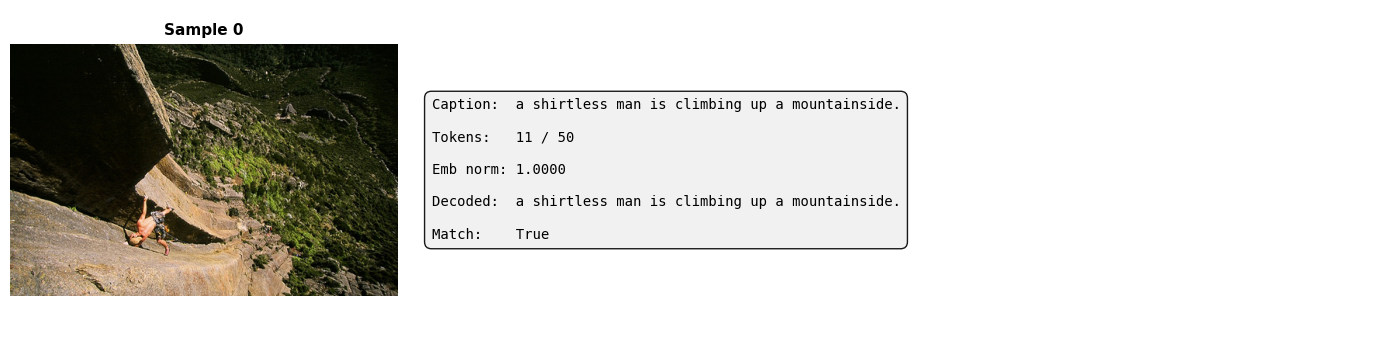

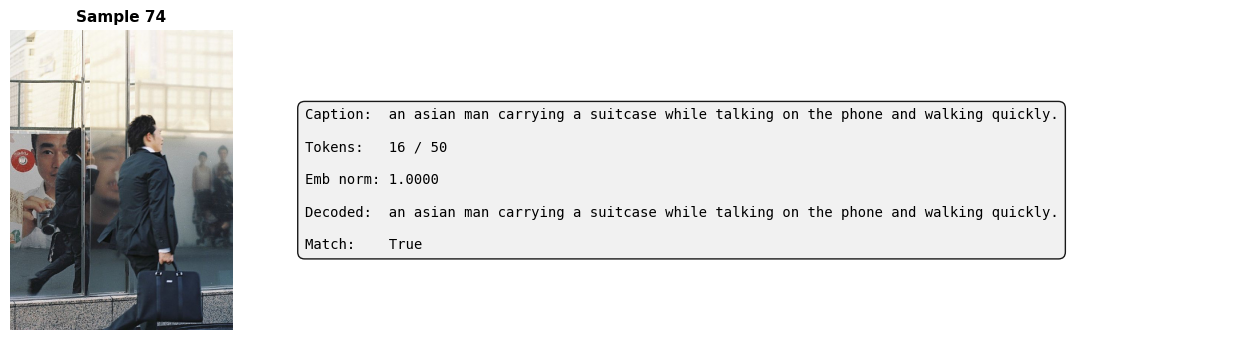

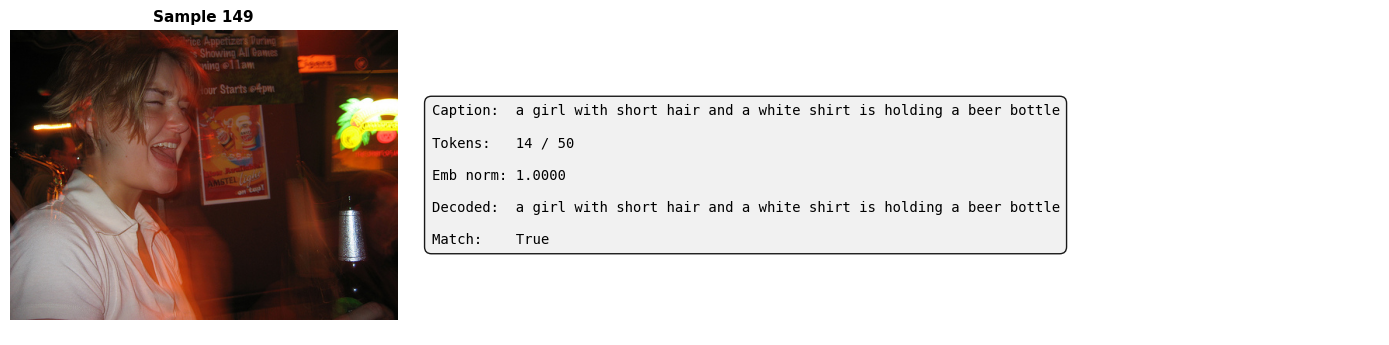

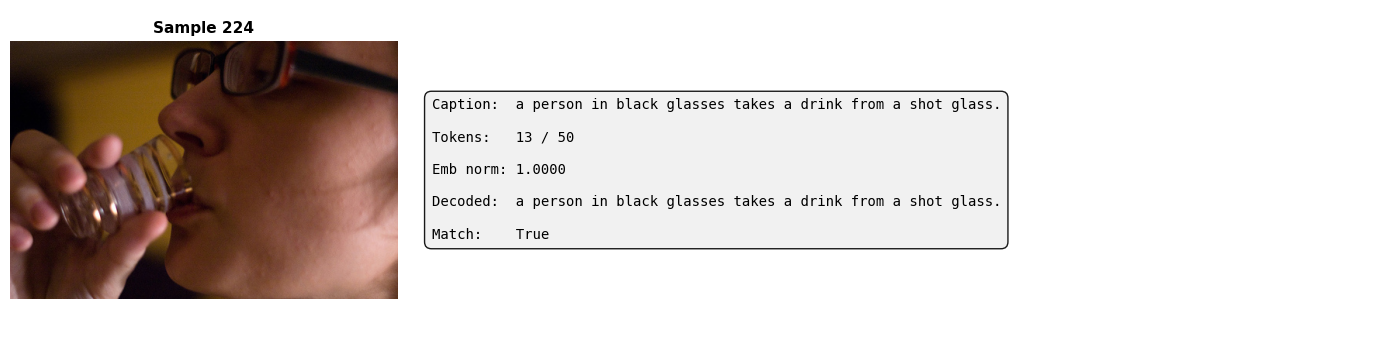

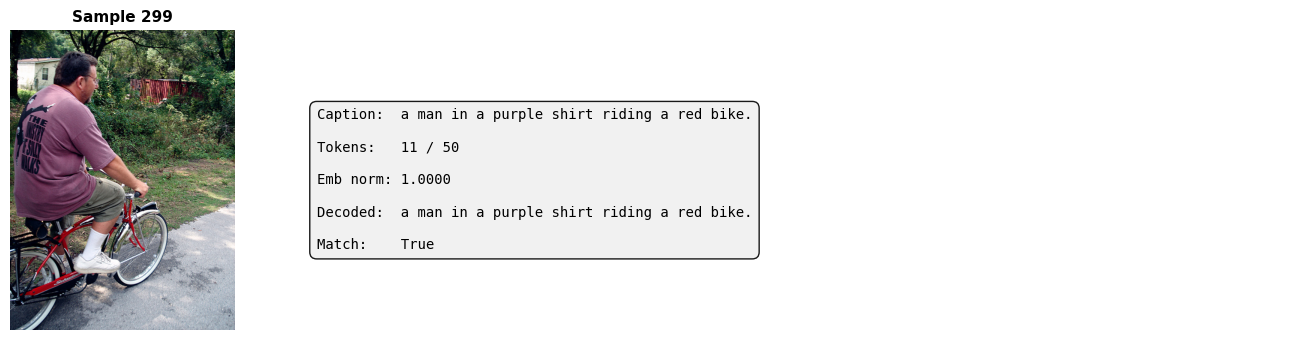

In [23]:
def run_sample_test(data, clip_enc, tok, idx, raw_dataset):
    record = data[idx]
    image = record["image"]
    if image.mode != "RGB":
        image = image.convert("RGB")
    embedding = clip_enc.encode_image(image)
    encoded = tok.encode(record["caption"])
    decoded = tok.decode(encoded["input_ids"])
    active = encoded["attention_mask"].sum().item()
    total = len(encoded["input_ids"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5),
                             gridspec_kw={"width_ratios": [1, 2.5]})
    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title(f"Sample {idx}", fontsize=11, fontweight="bold")

    text = (
        f"Caption:  {record['caption'][:85]}\n\n"
        f"Tokens:   {active} / {total}\n\n"
        f"Emb norm: {embedding.norm().item():.4f}\n\n"
        f"Decoded:  {decoded[:85]}\n\n"
        f"Match:    {decoded.strip() == record['caption'].strip()}"
    )
    axes[1].axis("off")
    axes[1].text(
        0.02, 0.50, text,
        transform=axes[1].transAxes,
        fontsize=10, verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.9),
    )
    plt.tight_layout()
    plt.show()


sample_indices = np.linspace(0, len(test_data) - 1, 5, dtype=int)
for idx in sample_indices:
    run_sample_test(test_data, clip_encoder, caption_tokenizer, idx, raw_dataset)

---
## 11. Embedding Space Sanity Check

Verify CLIP embeddings capture semantic similarity by computing pairwise cosine similarity across a small batch.

2026-02-27 18:14:41 [INFO]   Encoded 50/50 images


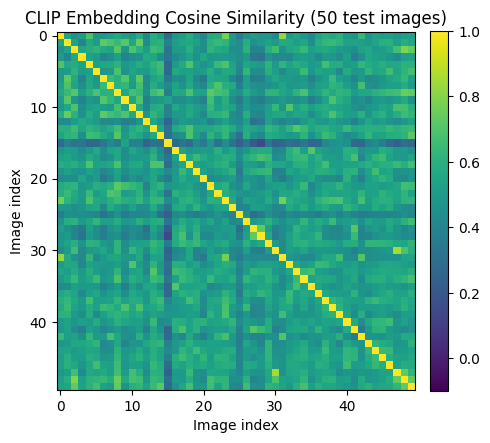

Off-diagonal cosine similarity:
  Mean: 0.5220
  Std:  0.0877
  Min:  0.1421
  Max:  0.8542


In [20]:
n_analysis = min(50, len(test_data))
analysis_images = []
for d in test_data[:n_analysis]:
    img = d["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    analysis_images.append(img)

analysis_embeddings = clip_encoder.encode_batch(analysis_images)
cos_sim = torch.mm(analysis_embeddings, analysis_embeddings.T)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cos_sim.numpy(), cmap="viridis", vmin=-0.1, vmax=1.0)
ax.set_title(f"CLIP Embedding Cosine Similarity ({n_analysis} test images)")
ax.set_xlabel("Image index")
ax.set_ylabel("Image index")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(
    os.path.join(cfg.outputs_dir, "figures", "embedding_similarity.png"), dpi=150
)
plt.show()

mask = ~torch.eye(n_analysis, dtype=torch.bool)
off_diag = cos_sim[mask]
print(f"Off-diagonal cosine similarity:")
print(f"  Mean: {off_diag.mean().item():.4f}")
print(f"  Std:  {off_diag.std().item():.4f}")
print(f"  Min:  {off_diag.min().item():.4f}")
print(f"  Max:  {off_diag.max().item():.4f}")

---
## 12. Pipeline Summary

| Component | Status | Output Shape |
|---|---|---|
| Dataset loading & cleaning | Complete | 3,000 image-caption pairs |
| Train / Val / Test split | Complete | 80% / 10% / 10% |
| CLIP image encoder | Verified | (B, 512) |
| GPT-2 tokenizer | Verified | (B, 50) |
| ProjectionHead (M2 prep) | Defined | (B, 10, 768) |
| Precomputed embeddings | Saved | `.pt` files |
| DataLoader | Tested | Batch-ready |

### Milestone #2 Integration Plan

1. Load saved embeddings from `data/embeddings/` (no CLIP recomputation)
2. Initialize GPT-2 decoder via `GPT2LMHeadModel.from_pretrained('gpt2')`
3. Train `ProjectionHead` to map CLIP -> GPT-2 prefix
4. Implement prefix conditioning: prepend projected embeddings to GPT-2 input
5. Compare greedy, beam search, and nucleus decoding strategies

In [21]:
print("Milestone #1 Pipeline Summary")
print("=" * 50)
print(f"Dataset:            {cfg.dataset_name} ({cfg.hf_dataset_id})")
print(f"Total samples:      {len(cleaned_data)}")
print(f"Train / Val / Test: {len(train_data)} / {len(val_data)} / {len(test_data)}")
print(f"CLIP model:         {cfg.clip_model_name}")
print(f"CLIP embedding dim: {cfg.clip_embedding_dim}")
print(f"GPT-2 model:        {cfg.gpt2_model_name}")
print(f"GPT-2 embedding dim:{cfg.gpt2_embedding_dim}")
print(f"Max token length:   {cfg.max_token_length}")
print(f"Device:             {cfg.device}")
print(f"Seed:               {cfg.seed}")
print(f"\nAll pipeline stages verified. Ready for Milestone #2.")

Milestone #1 Pipeline Summary
Dataset:            flickr30k (nlphuji/flickr30k)
Total samples:      3000
Train / Val / Test: 2400 / 300 / 300
CLIP model:         openai/clip-vit-base-patch32
CLIP embedding dim: 512
GPT-2 model:        gpt2
GPT-2 embedding dim:768
Max token length:   50
Device:             mps
Seed:               42

All pipeline stages verified. Ready for Milestone #2.
